In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
donnee_clean = pd.read_csv("../data/processed/immobilier_nettoyee.csv")

### 7. Feature Engineering 
Transformer toutes les colonnes catégorielles en nombres 
1. Label encoding (2 variables)
2. One-Hot Encoding (plus de 2 variables)

In [3]:
# Label encoding pour les 2 variables catégorielles

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

colonne_bollene = ['acces_route', 'eau_electricite', 'parking']

for col in colonne_bollene:
    donnee_clean[col] = le.fit_transform(donnee_clean[col])

donnee_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4980 entries, 0 to 4979
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   prix_million_Ar     4980 non-null   int64  
 1   superficie_m2       4980 non-null   float64
 2   nb_chambres         4980 non-null   int64  
 3   nb_etages           4980 non-null   int64  
 4   localisation        4980 non-null   str    
 5   acces_route         4980 non-null   int64  
 6   eau_electricite     4980 non-null   int64  
 7   type_connexion      4980 non-null   str    
 8   parking             4980 non-null   int64  
 9   type_sol            4980 non-null   str    
 10  etat_maison         4980 non-null   str    
 11  annee_construction  4980 non-null   int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 467.0 KB


In [4]:
# One-hot encoding des colonnes catégorielles 

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

colonne_categorique = ['localisation', 'type_connexion', 'type_sol', 'etat_maison']

# Encoder toutes les colonnes en une seule fois
encoded_cols = ohe.fit_transform(donnee_clean[colonne_categorique])

# Récupérer les noms des colonnes automatiquement
encoded_df = pd.DataFrame(
    encoded_cols, 
    columns=ohe.get_feature_names_out(colonne_categorique)
)

# Fusion avec le dataset original
donnee_clean_encodee = pd.concat(
    [donnee_clean.drop(columns=colonne_categorique), encoded_df],
    axis=1
)

donnee_clean_encodee.info()

<class 'pandas.DataFrame'>
RangeIndex: 4980 entries, 0 to 4979
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   prix_million_Ar          4980 non-null   int64  
 1   superficie_m2            4980 non-null   float64
 2   nb_chambres              4980 non-null   int64  
 3   nb_etages                4980 non-null   int64  
 4   acces_route              4980 non-null   int64  
 5   eau_electricite          4980 non-null   int64  
 6   parking                  4980 non-null   int64  
 7   annee_construction       4980 non-null   int64  
 8   localisation_periurbain  4980 non-null   float64
 9   localisation_rural       4980 non-null   float64
 10  localisation_urbain      4980 non-null   float64
 11  type_connexion_aucune    4980 non-null   float64
 12  type_connexion_fibre     4980 non-null   float64
 13  type_connexion_starlink  4980 non-null   float64
 14  type_sol_brut            4980 non-n

### 8. Gestion des outliers (Éviter que les valeurs extrêmes faussent le modèle)

<Axes: ylabel='prix_million_Ar'>

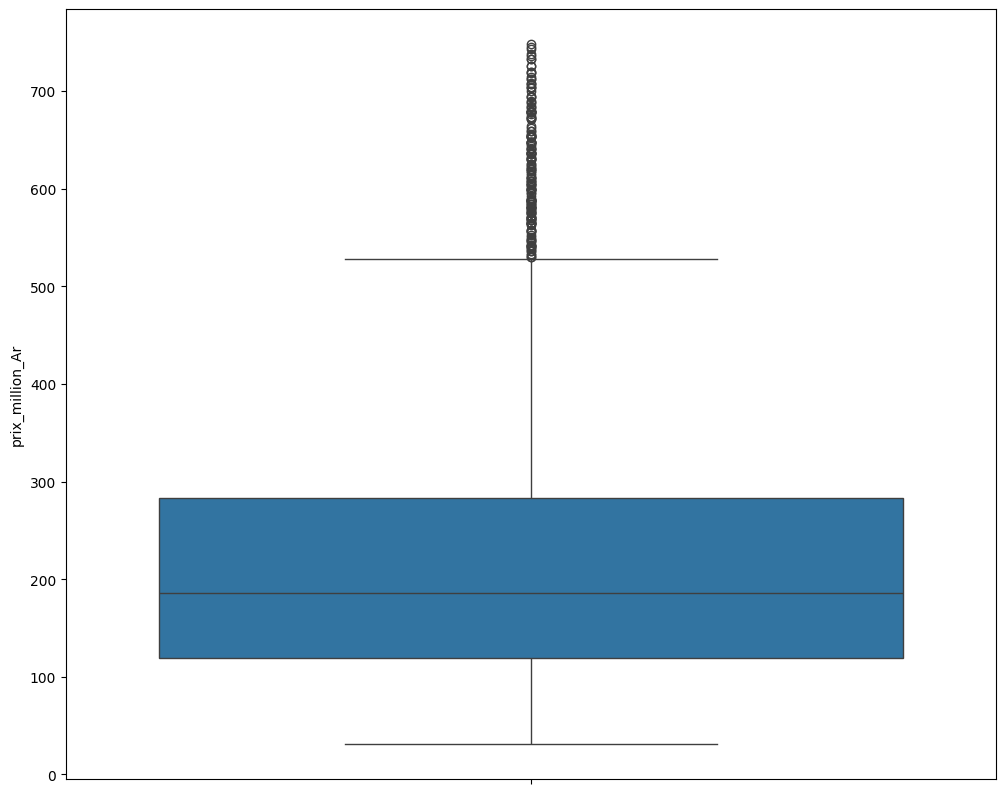

In [5]:
plt.figure(figsize=(12,10))
sns.boxplot(donnee_clean["prix_million_Ar"])

In [6]:
# Fonction pour detecter les outliers avec la méthode IQR
def detecter_outliers_iqr(data, colonne):
    Q1 = data[colonne].quantile(0.25)
    Q3 = data[colonne].quantile(0.75)
    IQR = Q3 - Q1
    seuil_inf = Q1 - 1.5 * IQR
    seuil_sup = Q3 + 1.5 * IQR
    print(f"Inf : {seuil_inf}, Sup : {seuil_sup} pour la colonne {colonne}")
    outliers = data[(data[colonne] < seuil_inf) | (data[colonne] > seuil_sup)]
    return outliers

# Détecter les outliers dans les colonnes prix, nb_chambres, nb_etages et annee_construction
colonnes_a_verifier = ['prix_million_Ar', 'nb_chambres', 'nb_etages', 'annee_construction']
for col in colonnes_a_verifier:
    outliers = detecter_outliers_iqr(donnee_clean_encodee, col)
    print(f"Outliers détectés dans la colonne '{col}': {len(outliers)}")
    print(outliers[[col]])
    print("\n")

Inf : -127.0, Sup : 529.0 pour la colonne prix_million_Ar
Outliers détectés dans la colonne 'prix_million_Ar': 183
      prix_million_Ar
14                545
36                588
62                600
69                575
115               575
...               ...
4798              540
4849              637
4880              570
4892              625
4947              578

[183 rows x 1 columns]


Inf : -1.0, Sup : 7.0 pour la colonne nb_chambres
Outliers détectés dans la colonne 'nb_chambres': 0
Empty DataFrame
Columns: [nb_chambres]
Index: []


Inf : -0.5, Sup : 3.5 pour la colonne nb_etages
Outliers détectés dans la colonne 'nb_etages': 0
Empty DataFrame
Columns: [nb_etages]
Index: []


Inf : 1972.5, Sup : 2040.5 pour la colonne annee_construction
Outliers détectés dans la colonne 'annee_construction': 0
Empty DataFrame
Columns: [annee_construction]
Index: []




In [7]:
# Supprimer les outliers détectés dans la colonne prix_million_Ar
Q1 = donnee_clean_encodee['prix_million_Ar'].quantile(0.25)
Q3 = donnee_clean_encodee['prix_million_Ar'].quantile(0.75)
IQR = Q3 - Q1
seuil_inf = Q1 - 1.5 * IQR
seuil_sup = Q3 + 1.5 * IQR
donnee_clean_encodee_iqr = donnee_clean_encodee[
    (donnee_clean_encodee['prix_million_Ar'] >= seuil_inf) & 
    (donnee_clean_encodee['prix_million_Ar'] <= seuil_sup)
]
donnee_clean_encodee_iqr.head()

donnee_clean_encodee_iqr_final = donnee_clean_encodee_iqr.copy()

In [8]:
# Enregistrer le dataset nettoyé et encodé

donnee_clean_encodee_iqr.to_csv('../data/processed/immobilier_encodee_iqr.csv', index=False)

### 9. Scaling (normalisation et standardisation) 
On utilise StandarScaler ou MinMaxScaler

In [9]:
# Code avec StandardScaler pour la normalisation des données numériques (moyenne 0 et écart-type 1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
colonnes_numeriques = ['prix_million_Ar', 'superficie_m2', 'nb_chambres', 'nb_etages', 'annee_construction']
donnee_clean_encodee_iqr[colonnes_numeriques] = scaler.fit_transform(donnee_clean_encodee_iqr[colonnes_numeriques])


donnee_Standard = donnee_clean_encodee_iqr.copy()

donnee_Standard.head()

donnee_Standard.to_csv('../data/processed/immobilier_encodee_standard.csv', index=False)

In [10]:
# Normalisation avec MinMaxScaler (valeurs entre 0 et 1)
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
donnee_clean_encodee_iqr[colonnes_numeriques] = minmax_scaler.fit_transform(donnee_clean_encodee_iqr[colonnes_numeriques])

donnee_MinMax = donnee_clean_encodee_iqr.copy()

donnee_MinMax.head()

donnee_MinMax.to_csv('../data/processed/immobilier_encodee_minmax.csv', index=False)

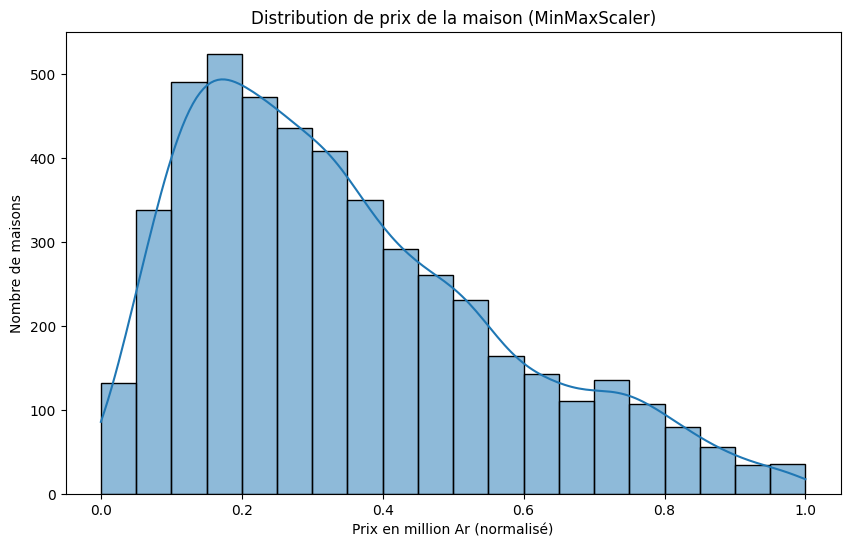

In [11]:
# Histogramme du prix des maisons en million Ar après normalisation avec StandardScaler
plt.figure(figsize=(10,6))
sns.histplot(donnee_MinMax["prix_million_Ar"], bins=20, kde=True)
plt.title("Distribution de prix de la maison (MinMaxScaler)")
plt.xlabel("Prix en million Ar (normalisé)")
plt.ylabel("Nombre de maisons")
plt.show()

### 10. Statistiques et validation (Valider les relations entre variables)

In [12]:
# Correlation des variable numérique avec le prix

numeric_cols = donnee_Standard.select_dtypes(include=["int64", "float64"]).columns

corr_matrix = donnee_Standard[numeric_cols].corr()

print(corr_matrix["prix_million_Ar"].sort_values(ascending=False))

# Évite régression linéaire simple pas suffisant ici)

prix_million_Ar            1.000000
superficie_m2              0.493800
localisation_urbain        0.481414
etat_maison_neuf           0.410581
nb_chambres                0.148077
localisation_periurbain    0.037625
type_sol_brut              0.025871
parking                    0.017392
type_connexion_fibre       0.004106
acces_route                0.002410
type_connexion_starlink    0.001186
etat_maison_bon           -0.000442
annee_construction        -0.002214
type_connexion_aucune     -0.005312
type_sol_ciment           -0.008044
nb_etages                 -0.008435
eau_electricite           -0.010502
type_sol_carrelage        -0.017782
etat_maison_a_renover     -0.398415
localisation_rural        -0.507187
Name: prix_million_Ar, dtype: float64


In [13]:
# T-test pour comparer les prix entre les maisons avec accès à la route et sans accès à la route
# montrent que les variables binaires (acces_route, eau_electricite, parking) ont un impact significatif sur le prix des maisons
from scipy.stats import ttest_ind

# Séparer les groupes
groupe_oui = donnee_Standard[donnee_Standard["parking"] == 1]["prix_million_Ar"]
groupe_non = donnee_Standard[donnee_Standard["parking"] == 0]["prix_million_Ar"]

# T-test
t_stat, p_value = ttest_ind(groupe_oui, groupe_non)

print("p-value:", p_value)

p-value: 0.22845263626446433


In [14]:
# T-test pour comparer les prix et plusieurs groupes

variables = ["acces_route", "eau_electricite", "parking"]

for col in variables:
    g1 = donnee_Standard[donnee_Standard[col] == 1]["prix_million_Ar"]
    g0 = donnee_Standard[donnee_Standard[col] == 0]["prix_million_Ar"]

    _, p = ttest_ind(g1, g0)
    print(f"{col} → p-value = {p}")

acces_route → p-value = 0.8674523739073622
eau_electricite → p-value = 0.46709755052157637
parking → p-value = 0.22845263626446433


In [15]:
# Randome forest pour évaluer l'importance des variables

from sklearn.ensemble import RandomForestRegressor

X = donnee_Standard.drop(columns=["prix_million_Ar"])
y = donnee_Standard["prix_million_Ar"]

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

superficie_m2              0.317662
localisation_rural         0.247758
etat_maison_neuf           0.156636
etat_maison_a_renover      0.093758
localisation_urbain        0.064591
localisation_periurbain    0.051907
nb_chambres                0.033416
etat_maison_bon            0.033191
annee_construction         0.000395
acces_route                0.000084
parking                    0.000072
nb_etages                  0.000071
type_connexion_fibre       0.000070
type_sol_carrelage         0.000068
eau_electricite            0.000067
type_sol_brut              0.000067
type_connexion_starlink    0.000066
type_sol_ciment            0.000063
type_connexion_aucune      0.000059
dtype: float64


### 11. Selection des variables utiles

#### Dataset final prêt pour ML 
On doit avoir :
- Pas de valeurs manquantes
- Pas de doublons
- Types corrects
- Variables encodées
- Variables scalées
- Features pertinentes


In [16]:
# Enregistrer le dataset nettoyé et transformé
donnee_clean_encodee_iqr_final.to_csv("../data/dataset_immobilier_final.csv", index=False)